#High Distribution Costs

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าฟอนต์และสไตล์กราฟ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'

# 1. โหลดข้อมูลจากไฟล์ Excel
file_path = 'fact_bookings.xlsx'
df_bookings = pd.read_excel(file_path, sheet_name='fact_bookings')
df_channels = pd.read_excel(file_path, sheet_name='dim_channels')
df_rate_codes = pd.read_excel(file_path, sheet_name='dim_rate_codes')

# 2. เชื่อมตาราง (Merge Tables)
df = pd.merge(df_bookings, df_channels, on='channel_id', how='left')
df = pd.merge(df, df_rate_codes, on='rate_code_id', how='left')

# 3. แปลงวันที่ และสร้าง Feature วันหยุด
df['check_in_date'] = pd.to_datetime(df['check_in_date'])
df['day_of_week'] = df['check_in_date'].dt.day_name()
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])

# 4. ฟังก์ชันคำนวณค่าคอมมิชชันและรายได้สุทธิ (ตัด Cancelled ทิ้ง)
def calc_commission(row):
    if row['status'] == 'Cancelled' or not row['is_commissionable']:
        return 0.0
    if row['commission_model'] == 'Percentage':
        return row['gross_room_revenue'] * row['default_commission_rate']
    elif row['commission_model'] == 'Flat Fee':
        return row['default_commission_rate']
    else:
        return 0.0

df['calculated_commission'] = df.apply(calc_commission, axis=1)
df['calculated_net_revenue'] = np.where(df['status'] == 'Cancelled', 0, df['gross_room_revenue'] - df['calculated_commission'])
df['opportunity_cost_from_cancel'] = np.where(df['status'] == 'Cancelled', df['gross_room_revenue'], 0)

print("✅ โหลดและคลีนข้อมูลเสร็จสิ้น! ตัวแปร 'df' พร้อมใช้งานสำหรับทุกคน")

✅ โหลดและคลีนข้อมูลเสร็จสิ้น! ตัวแปร 'df' พร้อมใช้งานสำหรับทุกคน


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Section 2 Analytical Design


## Hypothesis 1


--- สรุปผลสมมติฐานที่ 1 : True Net ADR 
  channel_type  total_true_net_revenue  total_checked_out_bookings  \
0       Direct                604077.0                         211   
1          OTA               1197205.0                         327   

   True_Net_ADR  
0   2862.924171  
1   3661.177370  


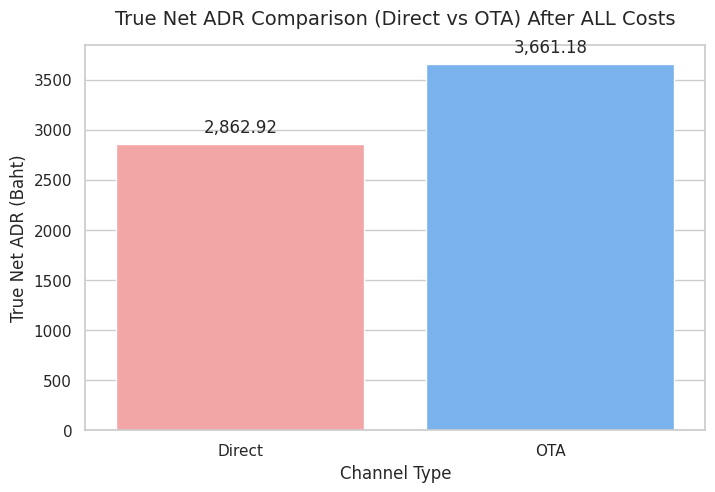


(กราฟที่ 1: True Net ADR Comparison)
- What to explore: ต้องการเจาะลึกเปรียบเทียบกำไรต่อบุ๊กกิ้ง (Net ADR) ระหว่างช่องทาง Direct และ OTA โดยหักลบ "ต้นทุนแฝงทั้งหมด" ซึ่งได้แก่ ค่าคอมมิชชัน (Commission) และ ค่าการตลาด (Marketing Spend / CAC) เพื่อประเมินความสามารถในการทำกำไรที่แท้จริง (True Net Profit per Booking)
- Why this chart is appropriate: การใช้ Bar Chart ทำให้เห็นภาพเปรียบเทียบอย่างชัดเจนว่า เมื่อเฉลี่ยต้นทุนค่าโฆษณา (ค่ายิงแอด) เข้าไปในแต่ละบุ๊กกิ้งแล้ว กำไรสุทธิต่อห้องที่แท้จริง (True Net ADR) ของ Direct Web เปลี่ยนแปลงไปอย่างไรเมื่อเทียบกับ OTA ซึ่งกราฟนี้จะช่วยไขข้อเท็จจริงเรื่องต้นทุนแฝง และนำไปสู่การวางแผนงบการตลาดที่แม่นยำขึ้น



In [ ]:
print("\n--- สรุปผลสมมติฐานที่ 1 : True Net ADR ")

# Re-using logic from Insight 1 for true net revenue calculation
# 1. Calculate revenue (Gross and Net) by Channel for Checked-Out bookings
#    and count checked-out bookings for ADR calculation
revenue_comparison_base = df[df['status'] == 'Checked-Out'].groupby(['channel_id', 'channel_name']).agg(
    gross_room_revenue=('gross_room_revenue', 'sum'),
    calculated_net_revenue=('calculated_net_revenue', 'sum'),
    checked_out_bookings=('booking_id', 'count') # Count only checked-out bookings for 'per room' basis
).reset_index()

# 2. Merge marketing spend (df_mkt only contains 'Direct Web' marketing spend)
mkt_total_spend = df_mkt.groupby('channel_id')['cost_amount'].sum().reset_index()
revenue_comparison_base = pd.merge(revenue_comparison_base, mkt_total_spend, on='channel_id', how='left').fillna(0)

# 3. Calculate true net revenue (after commission and marketing)
revenue_comparison_base['true_net_revenue'] = revenue_comparison_base['calculated_net_revenue'] - revenue_comparison_base['cost_amount']

# 4. Merge with df_channels to get channel_type (OTA, Direct, Wholesale)
revenue_comparison_base = pd.merge(revenue_comparison_base, df_channels[['channel_id', 'channel_type']], on='channel_id', how='left')

# 5. Filter for 'OTA' and 'Direct' channel types as per the original hypothesis
true_adr_df = revenue_comparison_base[revenue_comparison_base['channel_type'].isin(['OTA', 'Direct'])]

# 6. Group by channel_type to get total true net revenue and total checked-out bookings
true_adr_summary = true_adr_df.groupby('channel_type').agg(
    total_true_net_revenue=('true_net_revenue', 'sum'),
    total_checked_out_bookings=('checked_out_bookings', 'sum')
).reset_index()

# 7. Calculate True Net ADR (profit per room)
true_adr_summary['True_Net_ADR'] = true_adr_summary['total_true_net_revenue'] / true_adr_summary['total_checked_out_bookings']

print(true_adr_summary)

# 8. Plotting
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='channel_type', y='True_Net_ADR', data=true_adr_summary, hue='channel_type', palette=['#FF9999', '#66B2FF'], legend=False)
plt.title('True Net ADR Comparison (Direct vs OTA) After ALL Costs', fontsize=14, pad=15)
plt.ylabel('True Net ADR (Baht)', fontsize=12)
plt.xlabel('Channel Type', fontsize=12)

for p in ax.patches:
    ax.annotate(f"{p.get_height():,.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', xytext=(0, 8), textcoords='offset points')
plt.show()

print("""
(กราฟที่ 1: True Net ADR Comparison)
- What to explore: ต้องการเจาะลึกเปรียบเทียบกำไรต่อบุ๊กกิ้ง (Net ADR) ระหว่างช่องทาง Direct และ OTA โดยหักลบ "ต้นทุนแฝงทั้งหมด" ซึ่งได้แก่ ค่าคอมมิชชัน (Commission) และ ค่าการตลาด (Marketing Spend / CAC) เพื่อประเมินความสามารถในการทำกำไรที่แท้จริง (True Net Profit per Booking)
- Why this chart is appropriate: การใช้ Bar Chart ทำให้เห็นภาพเปรียบเทียบอย่างชัดเจนว่า เมื่อเฉลี่ยต้นทุนค่าโฆษณา (ค่ายิงแอด) เข้าไปในแต่ละบุ๊กกิ้งแล้ว กำไรสุทธิต่อห้องที่แท้จริง (True Net ADR) ของ Direct Web เปลี่ยนแปลงไปอย่างไรเมื่อเทียบกับ OTA ซึ่งกราฟนี้จะช่วยไขข้อเท็จจริงเรื่องต้นทุนแฝง และนำไปสู่การวางแผนงบการตลาดที่แม่นยำขึ้น
""")

## Hypothesis 2


--- สรุปผลสมมติฐานที่ 2: Commission Cost % ---


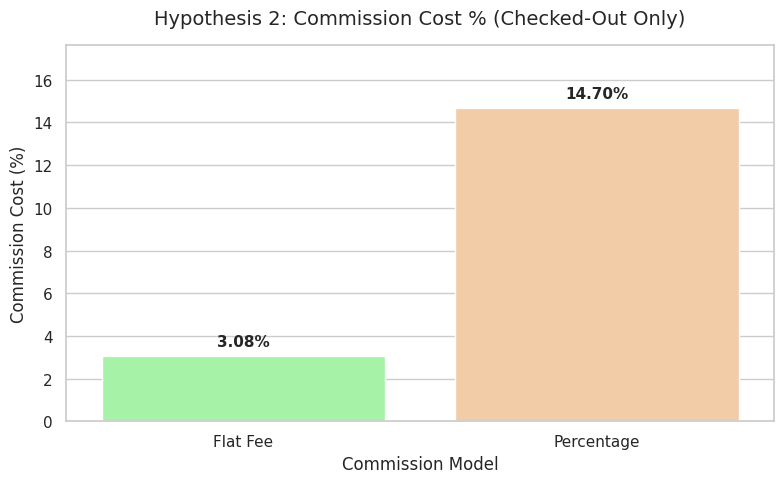


(กราฟที่ 2: Commission Cost %)
What to explore: วิเคราะห์ว่าโมเดลค่าคอมมิชชั่นแบบ Flat Fee และ Percentage มีสัดส่วนต้นทุนต่อรายได้ (Commission Cost %) แตกต่างกันอย่างไร เพื่อเข้าใจว่าโมเดลใดมี impact ต่อรายได้มากกว่า
Why this chart is appropriate: ใช้ Bar Chart เพื่อเปรียบเทียบสัดส่วน (%) ระหว่างโมเดลโดยตรง ทำให้เห็นชัดว่าโมเดลใดมีต้นทุนสูงกว่าเมื่อเทียบกับรายได้รวม



In [ ]:
print("\n--- สรุปผลสมมติฐานที่ 2: Commission Cost % ---")

# 1. กรองเอาเฉพาะคนที่ "เข้าพักจริง (Checked-Out)" และ โมเดลคอมมิชชันที่ต้องการ
h2_df = df[(df['status'] == 'Checked-Out') & (df['commission_model'].isin(['Flat Fee', 'Percentage']))]

# 2. คำนวณยอดรวม
h2_summary = h2_df.groupby('commission_model').agg(
    total_commission=('calculated_commission', 'sum'),
    total_gross_revenue=('gross_room_revenue', 'sum')
).reset_index()

# 3. หาเปอร์เซ็นต์
h2_summary['Cost_Percentage'] = (h2_summary['total_commission'] / h2_summary['total_gross_revenue']) * 100

# 4. วาดกราฟ
plt.figure(figsize=(8, 5))
ax2 = sns.barplot(
    x='commission_model',
    y='Cost_Percentage',
    data=h2_summary,
    hue='commission_model',
    palette=['#99FF99', '#FFCC99'],
    dodge=False,
    legend=False
)

plt.title('Hypothesis 2: Commission Cost % (Checked-Out Only)', fontsize=14, pad=15)
plt.ylabel('Commission Cost (%)', fontsize=12)
plt.xlabel('Commission Model', fontsize=12)

# ใส่ตัวเลขกำกับบนแท่งกราฟ
for p in ax2.patches:
    if p.get_height() > 0:
        ax2.annotate(f"{p.get_height():.2f}%",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom',
                     fontsize=11, fontweight='bold',
                     xytext=(0, 5), textcoords='offset points')

# เผื่อพื้นที่ด้านบนกราฟ
plt.ylim(0, h2_summary['Cost_Percentage'].max() * 1.2)
plt.tight_layout()
plt.show()
print("""
(กราฟที่ 2: Commission Cost %)
What to explore: วิเคราะห์ว่าโมเดลค่าคอมมิชชั่นแบบ Flat Fee และ Percentage มีสัดส่วนต้นทุนต่อรายได้ (Commission Cost %) แตกต่างกันอย่างไร เพื่อเข้าใจว่าโมเดลใดมี impact ต่อรายได้มากกว่า
Why this chart is appropriate: ใช้ Bar Chart เพื่อเปรียบเทียบสัดส่วน (%) ระหว่างโมเดลโดยตรง ทำให้เห็นชัดว่าโมเดลใดมีต้นทุนสูงกว่าเมื่อเทียบกับรายได้รวม
""")

## Hypothesis 3


--- Hypothesis 3: Weekend vs Weekday Performance (True Net ADR) ---


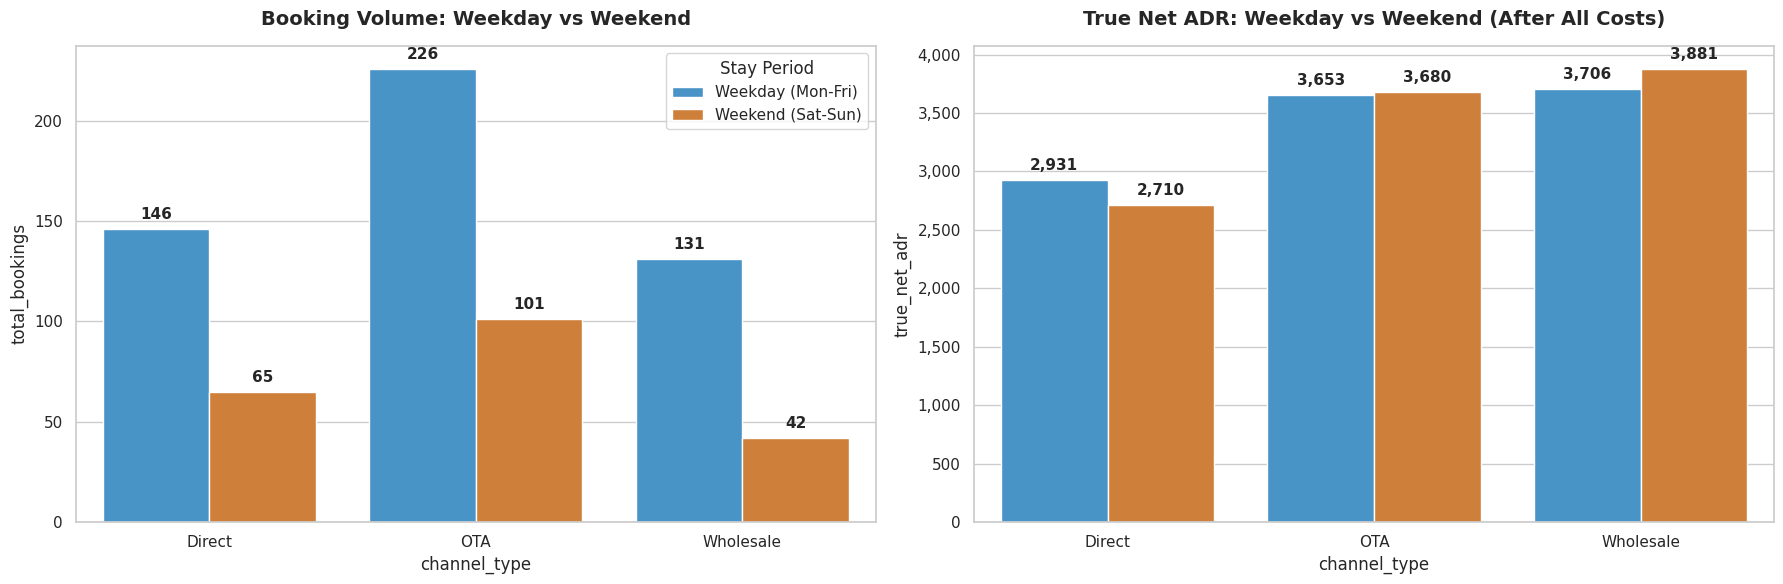


(กราฟที่ 3: Weekend vs Weekday Behavior)
- What to explore: ต้องการวิเคราะห์พฤติกรรมการเข้าพักระหว่าง "วันธรรมดา (Weekday)" และ "วันหยุด (Weekend)" ว่ามีความแตกต่างกันอย่างไร ทั้งในแง่ของปริมาณการจอง (Volume) ผ่านแต่ละช่องทาง และความสามารถในการทำกำไรต่อห้อง (Net ADR) เพื่อใช้เป็นแนวทางในการทำ Customer Segmentation
- Why this chart is appropriate: การใช้ Grouped Bar Chart 2 กราฟควบคู่กัน (Volume คู่กับ Value) ทำให้เห็นพฤติกรรมที่แตกต่างกันของลูกค้าได้อย่างชัดเจน เช่น วันหยุดอาจมียอดจองสูงจาก OTA แต่ในขณะเดียวกัน วันธรรมดาเราอาจจะได้ Net ADR ที่ดีกว่าจากลูกค้ากลุ่ม Corporate (Direct/Wholesale) 
- Insight & Action: ข้อมูลชุดนี้ชี้ให้เห็นรอยต่อของความต้องการเข้าพัก (Demand) นำไปสู่กลยุทธ์การออกแพ็กเกจส่งเสริมการขาย เช่น การทำแคมเปญ 'Work from Hotel' ในช่วงวันธรรมดาผ่าน Direct Web เพื่อดัน Occupancy หรือการใช้ Minimum Length of Stay (บังคับพัก 2 คืนขึ้นไป) ในวันหยุดสำหรับช่องทาง OTA เพื่อคุ้มครองกำไรครับ



In [ ]:
print("\n--- Hypothesis 3: Weekend vs Weekday Performance (True Net ADR) ---")

# -----------------------------
# 1. เตรียมข้อมูลพื้นฐาน (เฉพาะ Checked-Out)
# -----------------------------
h3_df = df[df['status'] == 'Checked-Out'].copy()
h3_df['Stay_Type'] = np.where(h3_df['is_weekend'] == True, 'Weekend (Sat-Sun)', 'Weekday (Mon-Fri)')

# -----------------------------
# 2. คำนวณ Marketing Cost ต่อ Booking สำหรับช่องทาง Direct
# -----------------------------
# หาค่าใช้จ่ายการตลาดรวมทั้งหมด
total_mkt_cost = df_mkt['cost_amount'].sum()

# หานับจำนวน Booking ทั้งหมดของ Direct (CH_03) ที่ Checked-Out
total_direct_bookings = h3_df[h3_df['channel_id'] == 'CH_03'].shape[0]

# คำนวณ Marketing Cost Per Booking (CAC)
# ใช้การเช็กเพื่อกัน Error กรณีหารด้วย 0
mkt_per_booking = total_mkt_cost / total_direct_bookings if total_direct_bookings > 0 else 0

# -----------------------------
# 3. สร้างคอลัมน์ True Net Revenue (หักคอมฯ และ หักค่าแอดเฉพาะ Direct)
# -----------------------------
def get_true_net(row):
    if row['channel_id'] == 'CH_03': # ถ้าเป็น Direct Web
        return row['calculated_net_revenue'] - mkt_per_booking
    else:
        return row['calculated_net_revenue']

h3_df['true_net_revenue'] = h3_df.apply(get_true_net, axis=1)

# -----------------------------
# 4. Group by เพื่อหาค่าเฉลี่ย True Net ADR
# -----------------------------
h3_summary = h3_df.groupby(['channel_type', 'Stay_Type']).agg(
    total_bookings=('booking_id', 'count'),
    true_net_adr=('true_net_revenue', 'mean')
).reset_index()

# -----------------------------
# 5. Visualization
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
custom_palette = {'Weekday (Mon-Fri)': '#3498db', 'Weekend (Sat-Sun)': '#e67e22'}

# --- Plot 1: Booking Volume ---
ax1 = sns.barplot(x='channel_type', y='total_bookings', hue='Stay_Type', data=h3_summary, palette=custom_palette, ax=axes[0])
axes[0].set_title('Booking Volume: Weekday vs Weekend', fontsize=14, fontweight='bold', pad=15)

for p in ax1.patches:
    if p.get_height() > 0:
        axes[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

# --- Plot 2: True Net ADR (หักค่าการตลาดแล้ว) ---
ax2 = sns.barplot(x='channel_type', y='true_net_adr', hue='Stay_Type', data=h3_summary, palette=custom_palette, ax=axes[1])
axes[1].set_title('True Net ADR: Weekday vs Weekend (After All Costs)', fontsize=14, fontweight='bold', pad=15)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

for p in ax2.patches:
    if p.get_height() > 0:
        axes[1].annotate(f"{p.get_height():,.0f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

axes[0].legend(title='Stay Period', loc='upper right')
if axes[1].get_legend(): axes[1].get_legend().remove()
plt.tight_layout()
plt.show()

print("""
(กราฟที่ 3: Weekend vs Weekday Behavior)
- What to explore: ต้องการวิเคราะห์พฤติกรรมการเข้าพักระหว่าง "วันธรรมดา (Weekday)" และ "วันหยุด (Weekend)" ว่ามีความแตกต่างกันอย่างไร ทั้งในแง่ของปริมาณการจอง (Volume) ผ่านแต่ละช่องทาง และความสามารถในการทำกำไรต่อห้อง (Net ADR) เพื่อใช้เป็นแนวทางในการทำ Customer Segmentation
- Why this chart is appropriate: การใช้ Grouped Bar Chart 2 กราฟควบคู่กัน (Volume คู่กับ Value) ทำให้เห็นพฤติกรรมที่แตกต่างกันของลูกค้าได้อย่างชัดเจน เช่น วันหยุดอาจมียอดจองสูงจาก OTA แต่ในขณะเดียวกัน วันธรรมดาเราอาจจะได้ Net ADR ที่ดีกว่าจากลูกค้ากลุ่ม Corporate (Direct/Wholesale)
- Insight & Action: ข้อมูลชุดนี้ชี้ให้เห็นรอยต่อของความต้องการเข้าพัก (Demand) นำไปสู่กลยุทธ์การออกแพ็กเกจส่งเสริมการขาย เช่น การทำแคมเปญ 'Work from Hotel' ในช่วงวันธรรมดาผ่าน Direct Web เพื่อดัน Occupancy หรือการใช้ Minimum Length of Stay (บังคับพัก 2 คืนขึ้นไป) ในวันหยุดสำหรับช่องทาง OTA เพื่อคุ้มครองกำไรครับ
""")

#Section 3 Data Execution & EDA

สิ่งที่ต้องการหาจากการทำ EDA: มีองค์ประกอบใดบ้างที่ทำให้ กำไรสุทธิ(Net Revenue) ลดลง

## Graph 1

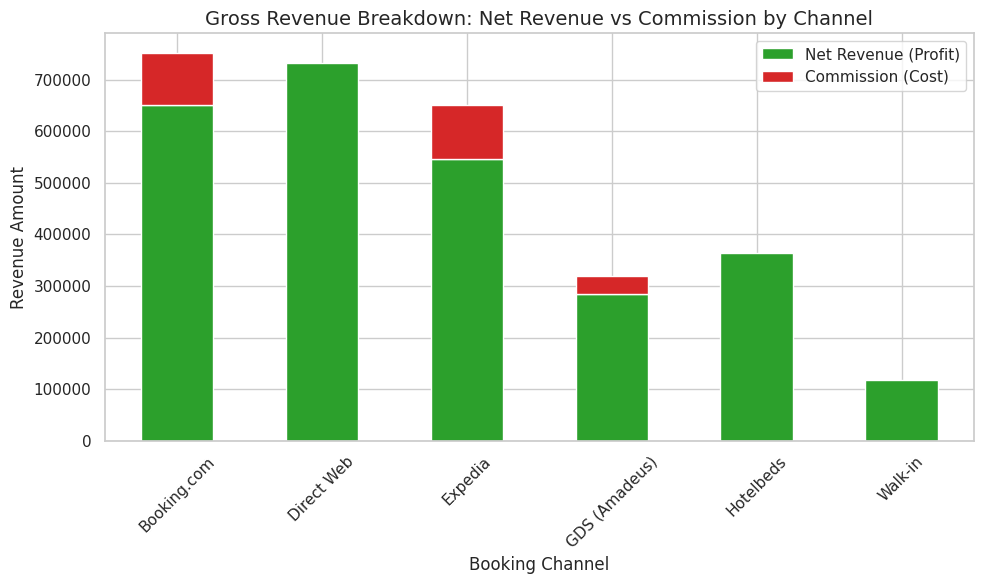


ข้อความสำหรับใส่รายงาน (กราฟที่ 1):
- What to explore: ต้องการตรวจสอบโครงสร้างรายได้ (Revenue Structure) ของแต่ละช่องทางการจอง ว่ายอดขายรวมที่สร้างได้นั้น ถูกหักเป็นต้นทุนค่าคอมมิชชันไปเท่าไหร่ และเหลือเป็นรายได้สุทธิ (Net Revenue) เข้าโรงแรมจริงๆ เท่าไหร่
- Why this chart is appropriate: เลือกใช้ '100% Stacked Bar Chart / Stacked Bar Chart' เพราะสามารถแสดง 'ขนาดของรายได้รวม (Gross)' ผ่านความสูงของแท่งกราฟ และ 'โครงสร้างสัดส่วน' ผ่านสีได้ในกราฟเดียว ทำให้ผู้บริหารเห็นภาพชัดเจนว่า ช่องทางที่สร้างยอดขายได้สูง อาจมีต้นทุนแฝง (พื้นที่สีแดง) ที่กัดกินกำไร (พื้นที่สีเขียว) ในสัดส่วนที่สูงตามไปด้วย



In [ ]:
# ==========================================
# กราฟที่ 1: เปรียบเทียบสัดส่วนรายได้สุทธิ (Net) และค่าคอมมิชชัน
# ==========================================
# เตรียมข้อมูล
revenue_summary = df[df['status'] == 'Checked-Out'].groupby('channel_name')[['calculated_net_revenue', 'calculated_commission']].sum().reset_index()

revenue_summary.set_index('channel_name').plot(kind='bar', stacked=True, color=['#2ca02c', '#d62728'])
plt.title('Gross Revenue Breakdown: Net Revenue vs Commission by Channel', fontsize=14)
plt.ylabel('Revenue Amount', fontsize=12)
plt.xlabel('Booking Channel', fontsize=12)
plt.xticks(rotation=45)
plt.legend(['Net Revenue (Profit)', 'Commission (Cost)'])
plt.tight_layout()
plt.show()

print("""
ข้อความสำหรับใส่รายงาน (กราฟที่ 1):
- What to explore: ต้องการตรวจสอบโครงสร้างรายได้ (Revenue Structure) ของแต่ละช่องทางการจอง ว่ายอดขายรวมที่สร้างได้นั้น ถูกหักเป็นต้นทุนค่าคอมมิชชันไปเท่าไหร่ และเหลือเป็นรายได้สุทธิ (Net Revenue) เข้าโรงแรมจริงๆ เท่าไหร่
- Why this chart is appropriate: เลือกใช้ '100% Stacked Bar Chart / Stacked Bar Chart' เพราะสามารถแสดง 'ขนาดของรายได้รวม (Gross)' ผ่านความสูงของแท่งกราฟ และ 'โครงสร้างสัดส่วน' ผ่านสีได้ในกราฟเดียว ทำให้ผู้บริหารเห็นภาพชัดเจนว่า ช่องทางที่สร้างยอดขายได้สูง อาจมีต้นทุนแฝง (พื้นที่สีแดง) ที่กัดกินกำไร (พื้นที่สีเขียว) ในสัดส่วนที่สูงตามไปด้วย
""")

## Graph 2

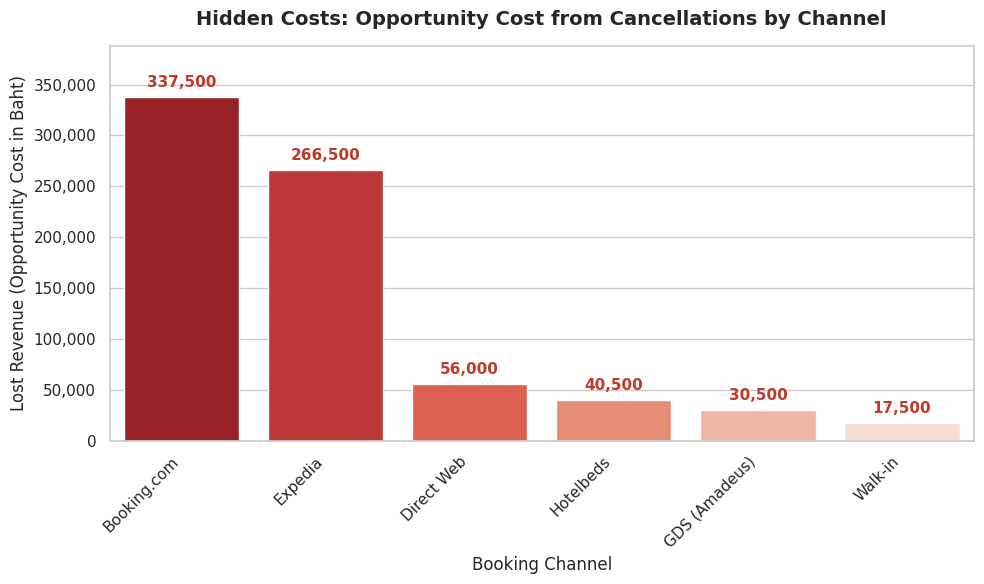


(EDA กราฟที่ 2: Opportunity Cost)
- What to explore: ต้องการชี้เป้าว่าช่องทางการจองใด (Channel Name) ที่มีพฤติกรรมการยกเลิก (Cancellation) สูง จนสร้างความเสียหายแฝง ทำให้โรงแรมสูญเสีย 'ค่าเสียโอกาส (Opportunity Cost)' ในการทำรายได้มากที่สุด
- Why this chart is appropriate: เลือกใช้ 'Sorted Bar Chart' (เรียงลำดับความเสียหายจากมากไปน้อย) ควบคู่กับการใช้หลักจิตวิทยาสี 'Reds Palette' (สีแดงไล่ระดับ) เพื่อสร้าง Visual Hierarchy เน้นย้ำ (Highlight) ให้ผู้บริหารเห็นช่องทางที่เป็น 'Root Cause' ของรายได้ที่รั่วไหล (Revenue Leakage) ได้อย่างรวดเร็วและทรงพลังที่สุด



In [ ]:
# ==========================================
# กราฟที่ 2: วิเคราะห์ "ต้นทุนค่าเสียโอกาส" จากการยกเลิกห้อง
# ==========================================
# 1. เตรียมข้อมูล
cancel_cost = df.groupby('channel_name')['opportunity_cost_from_cancel'].sum().reset_index()
cancel_cost = cancel_cost.sort_values(by='opportunity_cost_from_cancel', ascending=False)

# 2. วาดกราฟ
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=cancel_cost,
    x='channel_name',
    y='opportunity_cost_from_cancel',
    hue='channel_name',
    palette='Reds_r',
    legend=False
)

plt.title('Hidden Costs: Opportunity Cost from Cancellations by Channel', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Lost Revenue (Opportunity Cost in Baht)', fontsize=12)
plt.xlabel('Booking Channel', fontsize=12)
plt.xticks(rotation=45, ha='right')

# 3. ใส่ตัวเลขกำกับบนแท่งกราฟให้อ่านง่าย
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():,.0f}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom',
                     fontsize=11, fontweight='bold', color='#c0392b',
                     xytext=(0, 5), textcoords='offset points')

# 4. ปรับแกน Y ให้มีคอมม่า (,)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

# เผื่อพื้นที่ด้านบนกราฟไม่ให้ตัวเลขทะลุกรอบ
plt.ylim(0, cancel_cost['opportunity_cost_from_cancel'].max() * 1.15)
plt.tight_layout()
plt.show()

print("""
(EDA กราฟที่ 2: Opportunity Cost)
- What to explore: ต้องการชี้เป้าว่าช่องทางการจองใด (Channel Name) ที่มีพฤติกรรมการยกเลิก (Cancellation) สูง จนสร้างความเสียหายแฝง ทำให้โรงแรมสูญเสีย 'ค่าเสียโอกาส (Opportunity Cost)' ในการทำรายได้มากที่สุด
- Why this chart is appropriate: เลือกใช้ 'Sorted Bar Chart' (เรียงลำดับความเสียหายจากมากไปน้อย) ควบคู่กับการใช้หลักจิตวิทยาสี 'Reds Palette' (สีแดงไล่ระดับ) เพื่อสร้าง Visual Hierarchy เน้นย้ำ (Highlight) ให้ผู้บริหารเห็นช่องทางที่เป็น 'Root Cause' ของรายได้ที่รั่วไหล (Revenue Leakage) ได้อย่างรวดเร็วและทรงพลังที่สุด
""")

## Graph 3

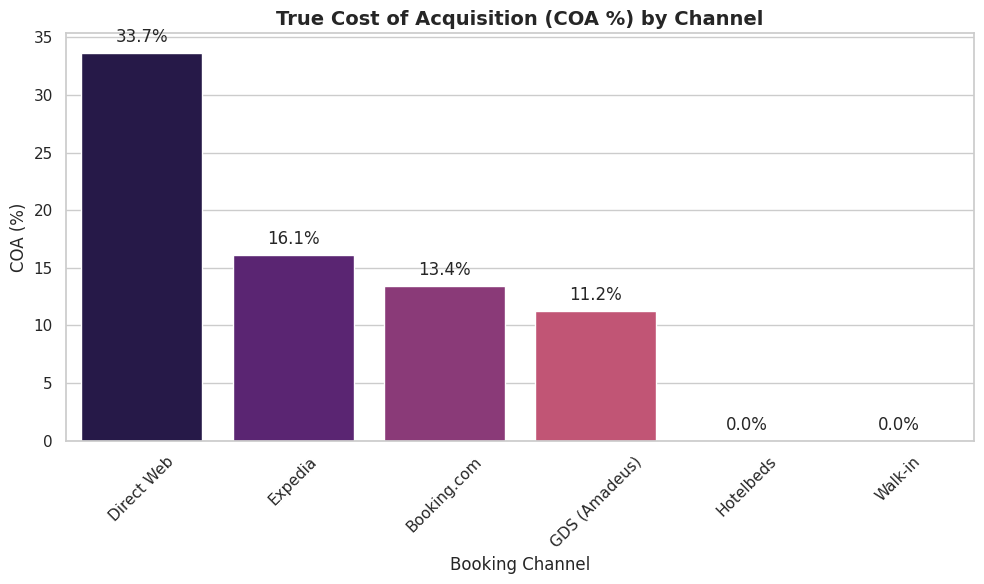


📝 ข้อความสำหรับใส่รายงาน (กราฟ COA %):
- What to explore: ต้องการหาต้นทุนการได้มาซึ่งลูกค้าที่แท้จริง (True Cost of Acquisition) โดยนำ "ค่าใช้จ่ายการตลาด" มารวมกับ "ค่าคอมมิชชัน" เพื่อดูว่าช่องทาง Direct Web ที่ไม่เสียค่าคอมฯ นั้น คุ้มค่าจริงหรือไม่เมื่อต้องจ่ายค่าโฆษณาเอง
- Why this chart is appropriate: เลือกใช้ 'Sorted Bar Chart' (กราฟแท่งเรียงลำดับ) เพื่อเปรียบเทียบสัดส่วน COA% ให้เห็นชัดเจนว่าช่องทางไหนมีต้นทุนต่อรายได้สูงที่สุด ซึ่งเป็นตัวชี้วัดที่สะท้อนประสิทธิภาพทางการเงินได้ดีกว่าการดูแค่ค่าคอมมิชชันเพียงอย่างเดียว



In [ ]:
# ==========================================
# กราฟ 3: True Cost of Acquisition (COA %)
# พิสูจน์ว่าช่องทาง Direct หรือ OTA ใครมีต้นทุนแพงกว่ากันแน่เมื่อรวมค่าโฆษณา
# ==========================================

# 1. โหลดข้อมูล Marketing Spend จากไฟล์ Excel หลัก (แก้ตรงนี้ให้ดึงจาก Sheet แทนครับ!)
df_mkt = pd.read_excel('fact_bookings.xlsx', sheet_name='fact_marketing_spend')

# 2. รวมยอดค่าใช้จ่ายการตลาด (Marketing Cost) แยกตาม Channel ID
marketing_summary = df_mkt.groupby('channel_id')['cost_amount'].sum().reset_index()

# นำไปเชื่อมกับตาราง df_channels (ตัวแปรที่มีอยู่แล้ว) เพื่อดึงชื่อ channel_name ออกมา
marketing_summary = pd.merge(marketing_summary, df_channels[['channel_id', 'channel_name']], on='channel_id', how='left')

# 3. รวมยอดรายได้รวม (Gross) และค่าคอมมิชชัน จากตารางหลัก (df)
booking_summary = df[df['status'] == 'Checked-Out'].groupby('channel_name').agg(
    total_gross_revenue=('gross_room_revenue', 'sum'),
    total_commission=('calculated_commission', 'sum')
).reset_index()

# 4. รวมข้อมูลรายได้/คอมมิชชัน เข้ากับข้อมูลค่าการตลาด (ถ้าช่องทางไหนไม่มีค่าการตลาดให้เป็น 0)
coa_df = pd.merge(booking_summary, marketing_summary[['channel_name', 'cost_amount']], on='channel_name', how='left').fillna(0)

# 5. คำนวณต้นทุนรวม (Total Acquisition Cost) และ COA %
coa_df['total_acquisition_cost'] = coa_df['total_commission'] + coa_df['cost_amount']
coa_df['COA_Percentage'] = (coa_df['total_acquisition_cost'] / coa_df['total_gross_revenue']) * 100

# 6. วาดกราฟแท่งเปรียบเทียบ
plt.figure(figsize=(10, 6))
ax_coa = sns.barplot(
    x='channel_name',
    y='COA_Percentage',
    data=coa_df.sort_values('COA_Percentage', ascending=False),
    hue='channel_name',
    palette='magma',
    legend=False
)

plt.title('True Cost of Acquisition (COA %) by Channel', fontsize=14, fontweight='bold')
plt.ylabel('COA (%)', fontsize=12)
plt.xlabel('Booking Channel', fontsize=12)
plt.xticks(rotation=45)

# ใส่ตัวเลขกำกับบนแท่งกราฟ
for p in ax_coa.patches:
    ax_coa.annotate(f"{p.get_height():,.1f}%",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()

print("""
📝 ข้อความสำหรับใส่รายงาน (กราฟ COA %):
- What to explore: ต้องการหาต้นทุนการได้มาซึ่งลูกค้าที่แท้จริง (True Cost of Acquisition) โดยนำ "ค่าใช้จ่ายการตลาด" มารวมกับ "ค่าคอมมิชชัน" เพื่อดูว่าช่องทาง Direct Web ที่ไม่เสียค่าคอมฯ นั้น คุ้มค่าจริงหรือไม่เมื่อต้องจ่ายค่าโฆษณาเอง
- Why this chart is appropriate: เลือกใช้ 'Sorted Bar Chart' (กราฟแท่งเรียงลำดับ) เพื่อเปรียบเทียบสัดส่วน COA% ให้เห็นชัดเจนว่าช่องทางไหนมีต้นทุนต่อรายได้สูงที่สุด ซึ่งเป็นตัวชี้วัดที่สะท้อนประสิทธิภาพทางการเงินได้ดีกว่าการดูแค่ค่าคอมมิชชันเพียงอย่างเดียว
""")

## Graph 4

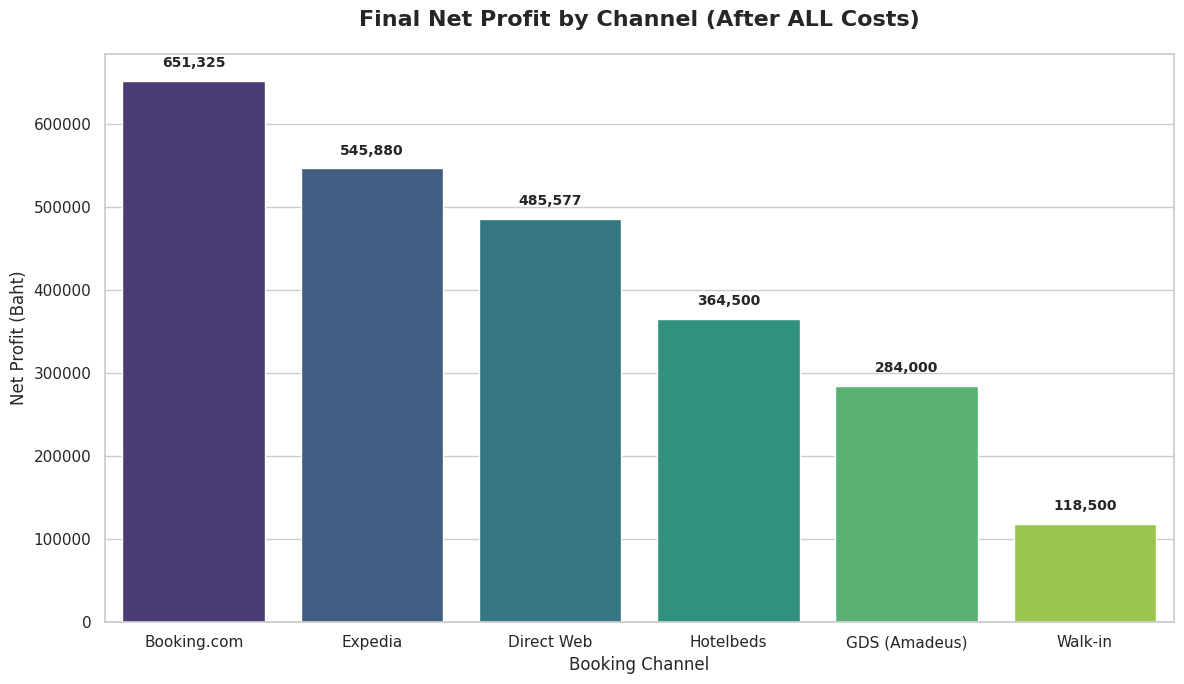


- What to explore: วิเคราะห์ "ผลกำไรที่แท้จริง" (Contribution Margin) ของแต่ละช่องทาง โดยนำรายได้รวมมาหักออกด้วยต้นทุนผันแปรทั้งหมด (ค่าคอมมิชชัน + ค่าใช้จ่ายการตลาด)
- Why this chart is appropriate: เลือกใช้ Bar Chart เรียงลำดับเพื่อให้เห็น "ผู้ชนะ" ในเชิงกำไรได้อย่างชัดเจนที่สุด ช่วยให้ผู้บริหารตัดสินใจได้ทันทีว่าควรลงทุนในช่องทางใดต่อ



In [ ]:
# ==========================================
# กราฟที่ 4: กำไรจริงๆ
# ==========================================
# 1. เตรียมข้อมูล Marketing Spend (ดึงจาก Excel Sheet)
df_mkt = pd.read_excel('fact_bookings.xlsx', sheet_name='fact_marketing_spend')
mkt_summary = df_mkt.groupby('channel_id')['cost_amount'].sum().reset_index()

# 2. เตรียมข้อมูล Revenue และ Commission (จากตัวแปร df หลัก)
# เลือกเฉพาะรายการที่เข้าพักจริง (Checked-Out)
booking_summary = df[df['status'] == 'Checked-Out'].groupby('channel_id').agg(
    total_gross=('gross_room_revenue', 'sum'),
    total_commission=('calculated_commission', 'sum')
).reset_index()

# 3. นำข้อมูลมารวมกันและหักลบเพื่อหากำไรสุดท้าย
final_df = pd.merge(booking_summary, mkt_summary, on='channel_id', how='left').fillna(0)
final_df = pd.merge(final_df, df_channels[['channel_id', 'channel_name']], on='channel_id', how='left')

# สูตรคำนวณ: กำไรสุดท้าย = รายได้รวม - ค่าคอมฯ - ค่าโฆษณา
final_df['final_profit'] = final_df['total_gross'] - final_df['total_commission'] - final_df['cost_amount']

# 4. วาดกราฟเปรียบเทียบกำไรสุทธิสุดท้าย
final_df = final_df.sort_values('final_profit', ascending=False)

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x='channel_name',
    y='final_profit',
    data=final_df,
    hue='channel_name',
    palette='viridis',
    legend=False
)

plt.title('Final Net Profit by Channel (After ALL Costs)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Net Profit (Baht)', fontsize=12)
plt.xlabel('Booking Channel', fontsize=12)

# ใส่ตัวเลขกำกับยอดกำไรบนแท่งกราฟ
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', xytext=(0, 10), textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("""
- What to explore: วิเคราะห์ "ผลกำไรที่แท้จริง" (Contribution Margin) ของแต่ละช่องทาง โดยนำรายได้รวมมาหักออกด้วยต้นทุนผันแปรทั้งหมด (ค่าคอมมิชชัน + ค่าใช้จ่ายการตลาด)
- Why this chart is appropriate: เลือกใช้ Bar Chart เรียงลำดับเพื่อให้เห็น "ผู้ชนะ" ในเชิงกำไรได้อย่างชัดเจนที่สุด ช่วยให้ผู้บริหารตัดสินใจได้ทันทีว่าควรลงทุนในช่องทางใดต่อ
""")

In [ ]:
# df['booking_month'] = df['booking_date'].dt.to_period('M').astype(str)

# monthly_revenue = df.groupby('booking_month')['gross_room_revenue'].sum().reset_index()
# monthly_revenue['booking_month'] = pd.to_datetime(monthly_revenue['booking_month'])

# monthly_revenue.head()

In [ ]:
# plt.figure(figsize=(12, 6))

# sns.lineplot(
#     data=monthly_revenue,
#     x='booking_month',
#     y='gross_room_revenue',
#     marker='o',
#     color='coral',
#     linewidth=2.5,
#     markersize=8
# )

# plt.title('Monthly Gross Room Revenue Trend', fontsize=14, fontweight='bold')
# plt.ylabel('Gross Room Revenue (Baht)')
# plt.xlabel('Booking Month')

# plt.xticks(rotation=45)
# plt.grid(True, linestyle='--', alpha=0.7)

# plt.tight_layout()
# plt.show()

# Section 4 Insights & Impact

In [ ]:
# Merge ข้อมูลสำหรับการวิเคราะห์
merged_data = df_bookings.merge(df_channels, on='channel_id', how='left') \
                           .merge(df_rate_codes, on='rate_code_id', how='left')

merged_data.head()

,booking_id,booking_date,check_in_date,channel_id,Channel Name,rate_code_id,gross_room_revenue,Commission Rate,commission_amount,net_room_revenue,status,channel_name,channel_type,commission_model,default_commission_rate,contract_owner,rate_name,is_commissionable
0,BK_00001,2022-12-06,2023-01-10,CH_06,Walk-in,RT_RACK,2500,0.00,0,2500,Checked-Out,Walk-in,Direct,Flat Fee,0.00,Charlie,Rack Rate,True
1,BK_00002,2023-04-22,2023-05-11,CH_01,Booking.com,RT_CORP,3000,0.15,450,2550,Checked-Out,Booking.com,OTA,Percentage,0.15,Alice,Corporate,True
2,BK_00003,2022-11-14,2023-01-02,CH_02,Expedia,RT_CORP,8000,0.18,1440,6560,Checked-Out,Expedia,OTA,Percentage,0.18,Bob,Corporate,True
3,BK_00004,2023-09-09,2023-09-27,CH_04,GDS (Amadeus),RT_RACK,2500,500.00,500,2000,Checked-Out,GDS (Amadeus),Wholesale,Flat Fee,500.00,Diana,Rack Rate,True
4,BK_00005,2023-01-11,2023-03-25,CH_05,Hotelbeds,RT_NET,2500,0.20,0,2500,Checked-Out,Hotelbeds,Wholesale,Merchant,0.20,Eve,Wholesale Net,False


## Insight 1

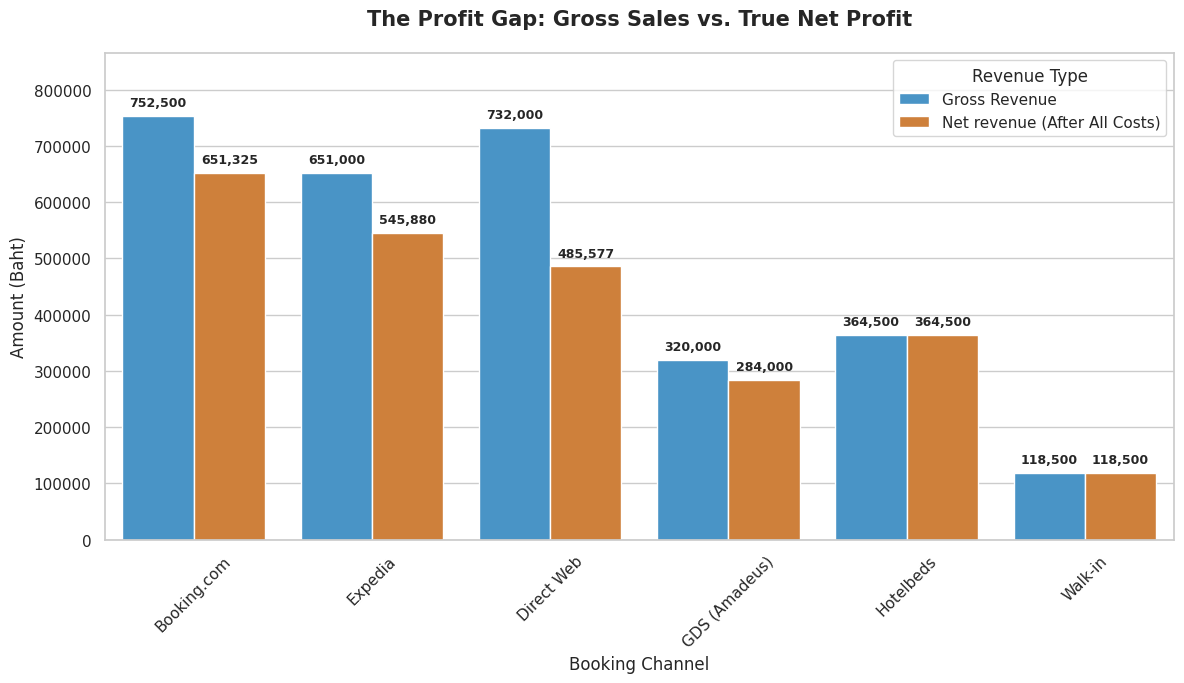


สรุปสิ่งที่เห็นจากกราฟ:
- แท่งสีฟ้า (Gross Sales): ยอดขายรวมที่ลูกค้าจ่าย
- แท่งสีส้ม (Net Profit): กำไรที่โรงแรมได้รับจริงหลังหักค่าคอมมิชชัน หรือค่าโฆษณาแล้ว


- What the data tells us: จากกราฟเปรียบเทียบส่วนต่างกำไร (The Profit Gap) หลังจากที่เรานำรายได้มาหักลบด้วย "ต้นทุนแฝงทั้งหมด" (ทั้งค่าคอมมิชชันของ OTA และค่าโฆษณาของ Direct Web) จะเห็นได้ชัดเจนว่าแท่งสีส้ม (True Net Profit) ของช่องทาง OTA ดรอปลงจากยอดขาย (แท่งสีฟ้า) อย่างหนักหน่วง ในขณะที่ช่องทาง Direct Web แม้จะมีการหักค่าโฆษณาออกไปแล้ว แต่ก็ยังรักษาสัดส่วนกำไรได้ดีกว่ามาก
- Business Impact: ข้อมูลนี้ยืนยันว่า การพึ่งพายอดขายจาก OTA ทำให้โรงแรมสูญเสียกำไร (Margin Erosion) ไปมหาศาล ในขณะที่ Direct Web แม้จะต้องลงทุนซื้อโฆษณา (Acquisition Cost) แต่เมื่อหักลบแล้วก็ยังเป็นช่องทางที่สร้างกำไรสุทธิ (Bottom-line Profit) ให้โรงแรมได้คุ้มค่าที่สุด
- Recommendation: เสนอให้ใช้กลยุทธ์ "Balanced Distribution" (รักษาสมดุลช่องทางขาย) ดังนี้:
  1. ชะลอการทำ Marketing ของ Direct Web: ไม่ควรทุ่มงบการตลาดเพิ่มไปที่ Direct Web ทันที จนกว่าจะมี

In [ ]:
# ==========================================
# Insight 1: กราฟเปรียบเทียบส่วนต่างกำไร (The Profit Gap)
# ==========================================
plt.figure(figsize=(12, 7))

# 1. คำนวณรายได้ (Gross และ Net เบื้องต้น) แยกตาม Channel
revenue_comparison = df[df['status'] == 'Checked-Out'].groupby(['channel_id', 'channel_name']).agg(
    gross_room_revenue=('gross_room_revenue', 'sum'),
    calculated_net_revenue=('calculated_net_revenue', 'sum')
).reset_index()

# 2. รวมยอดค่าใช้จ่ายการตลาด และหักลบออกจาก Direct Web
mkt_total_spend = df_mkt.groupby('channel_id')['cost_amount'].sum().reset_index()
revenue_comparison = pd.merge(revenue_comparison, mkt_total_spend, on='channel_id', how='left').fillna(0)
revenue_comparison['true_net_revenue'] = revenue_comparison['calculated_net_revenue'] - revenue_comparison['cost_amount']

# 3. Reshape data เพื่อวาดกราฟ
revenue_melted = revenue_comparison.melt(
    id_vars='channel_name',
    value_vars=['gross_room_revenue', 'true_net_revenue'],
    var_name='Revenue Type',
    value_name='Amount'
)

# 4. วาดกราฟ
ax = sns.barplot(
    data=revenue_melted,
    x='channel_name',
    y='Amount',
    hue='Revenue Type',
    palette=['#3498db', '#e67e22']
)

# ใส่ตัวเลขกำกับยอดเงินบนแท่งกราฟ
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():,.0f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom',
                    fontsize=9, fontweight='bold',
                    xytext=(0, 5), textcoords='offset points')

plt.title('The Profit Gap: Gross Sales vs. True Net Profit', fontweight='bold', fontsize=15, pad=20)
plt.ylabel('Amount (Baht)', fontsize=12)
plt.xlabel('Booking Channel', fontsize=12)
plt.xticks(rotation=45)

# แก้ไข Legend ให้แสดงสัญลักษณ์สีให้ถูกต้อง
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Gross Revenue', 'Net revenue (After All Costs)'], title='Revenue Type', loc='upper right')

# เพิ่มเพดานกราฟเพื่อให้ตัวเลขไม่ซ้อนขอบ
plt.ylim(0, revenue_comparison['gross_room_revenue'].max() * 1.15)

plt.tight_layout()
plt.show()

print("""
สรุปสิ่งที่เห็นจากกราฟ:
- แท่งสีฟ้า (Gross Sales): ยอดขายรวมที่ลูกค้าจ่าย
- แท่งสีส้ม (Net Profit): กำไรที่โรงแรมได้รับจริงหลังหักค่าคอมมิชชัน หรือค่าโฆษณาแล้ว
""")

print("""
- What the data tells us: จากกราฟเปรียบเทียบส่วนต่างกำไร (The Profit Gap) หลังจากที่เรานำรายได้มาหักลบด้วย "ต้นทุนแฝงทั้งหมด" (ทั้งค่าคอมมิชชันของ OTA และค่าโฆษณาของ Direct Web) จะเห็นได้ชัดเจนว่าแท่งสีส้ม (True Net Profit) ของช่องทาง OTA ดรอปลงจากยอดขาย (แท่งสีฟ้า) อย่างหนักหน่วง ในขณะที่ช่องทาง Direct Web แม้จะมีการหักค่าโฆษณาออกไปแล้ว แต่ก็ยังรักษาสัดส่วนกำไรได้ดีกว่ามาก
- Business Impact: ข้อมูลนี้ยืนยันว่า การพึ่งพายอดขายจาก OTA ทำให้โรงแรมสูญเสียกำไร (Margin Erosion) ไปมหาศาล ในขณะที่ Direct Web แม้จะต้องลงทุนซื้อโฆษณา (Acquisition Cost) แต่เมื่อหักลบแล้วก็ยังเป็นช่องทางที่สร้างกำไรสุทธิ (Bottom-line Profit) ให้โรงแรมได้คุ้มค่าที่สุด
- Recommendation: เสนอให้ใช้กลยุทธ์ "Balanced Distribution" (รักษาสมดุลช่องทางขาย) ดังนี้:
  1. ชะลอการทำ Marketing ของ Direct Web: ไม่ควรทุ่มงบการตลาดเพิ่มไปที่ Direct Web ทันที จนกว่าจะมีการแก้ปัญหาคอขวดที่หน้าเว็บไซต์ (เพิ่ม Conversion Rate) เพื่อให้ค่าแอดที่จ่ายไปคุ้มค่าขึ้น
  2. ปั้น Loyalty Program: เมื่อลูกค้าที่จองผ่าน OTA เดินทางมาเข้าพัก ให้พนักงานหน้าฟรอนต์เสนอสิทธิพิเศษเพื่อดึงลูกค้ากลุ่มนี้ให้สมัครสมาชิก เพื่อให้การจองครั้งถัดไปพวกเขาเปลี่ยนมาจองตรง (Direct) โดยที่โรงแรมไม่ต้องเสียทั้งค่าคอมฯ และค่าแอด
""")

## Insight 2

<Figure size 1000x600 with 0 Axes>

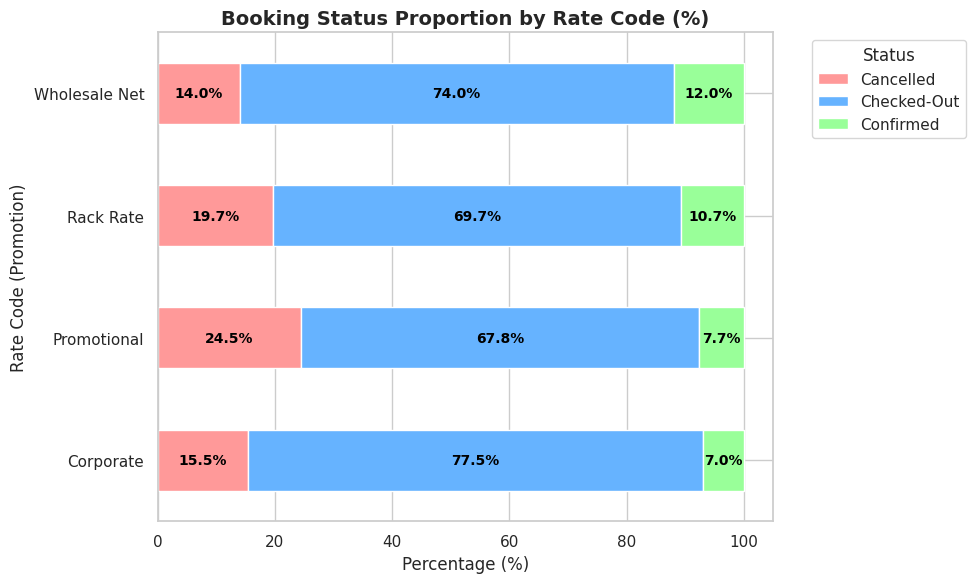


- What the data tells us: จากการวิเคราะห์พฤติกรรมลูกค้าเชิงลึก (Root Cause Analysis) ผ่านสัดส่วน 100% Stacked Bar Chart เราพบความผิดปกติว่าโปรโมชันรหัส Promotional ดึงดูดกลุ่มลูกค้าที่จองเข้ามากั๊กห้องแล้วยกเลิก (Serial Cancellers) สูงถึง 24.5% ซึ่งสูงกว่าโปรโมชันปกติอย่างชัดเจน
- Business Impact: พฤติกรรมนี้ทำให้โรงแรมเสียโอกาสในการขายห้องพักให้ลูกค้าตัวจริง (Opportunity Cost) และสูญเสียรายได้
- Recommendation: เสนอให้ฝ่ายการตลาดปรับเงื่อนไขของ Rate Code ตัวนี้ใหม่ เช่น เปลี่ยนเป็นแบบ Non-refundable (ไม่คืนเงินเมื่อยกเลิก) หรือต้องมัดจำล่วงหน้า เพื่อป้องกัน Serial Cancellers



In [ ]:
# ==========================================
# Insight 2: เปรียบเทียบสถานะการจองแยกตาม Rate Code (โปรโมชัน)
# ==========================================
# เตรียมข้อมูลสัดส่วน %
cross_tab = pd.crosstab(df['rate_name'], df['status'], normalize='index') * 100

# วาดกราฟและเก็บค่าไว้ในตัวแปร ax
plt.figure(figsize=(10, 6))
ax = cross_tab.plot(kind='barh', stacked=True, color=['#ff9999', '#66b3ff', '#99ff99'], figsize=(10,6))

plt.title('Booking Status Proportion by Rate Code (%)', fontsize=14, fontweight='bold')
plt.xlabel('Percentage (%)', fontsize=12)
plt.ylabel('Rate Code (Promotion)', fontsize=12)
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')

for c in ax.containers:
    # ใส่ตัวเลขทศนิยม 1 ตำแหน่ง (ถ้าค่าน้อยกว่า 1% จะไม่แสดงเพื่อไม่ให้กราฟรก)
    labels = [f'{w:.1f}%' if (w := v.get_width()) > 1 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

print("""
- What the data tells us: จากการวิเคราะห์พฤติกรรมลูกค้าเชิงลึก (Root Cause Analysis) ผ่านสัดส่วน 100% Stacked Bar Chart เราพบความผิดปกติว่าโปรโมชันรหัส Promotional ดึงดูดกลุ่มลูกค้าที่จองเข้ามากั๊กห้องแล้วยกเลิก (Serial Cancellers) สูงถึง 24.5% ซึ่งสูงกว่าโปรโมชันปกติอย่างชัดเจน
- Business Impact: พฤติกรรมนี้ทำให้โรงแรมเสียโอกาสในการขายห้องพักให้ลูกค้าตัวจริง (Opportunity Cost) และสูญเสียรายได้
- Recommendation: เสนอให้ฝ่ายการตลาดปรับเงื่อนไขของ Rate Code ตัวนี้ใหม่ เช่น เปลี่ยนเป็นแบบ Non-refundable (ไม่คืนเงินเมื่อยกเลิก) หรือต้องมัดจำล่วงหน้า เพื่อป้องกัน Serial Cancellers
""")

## Insight 3

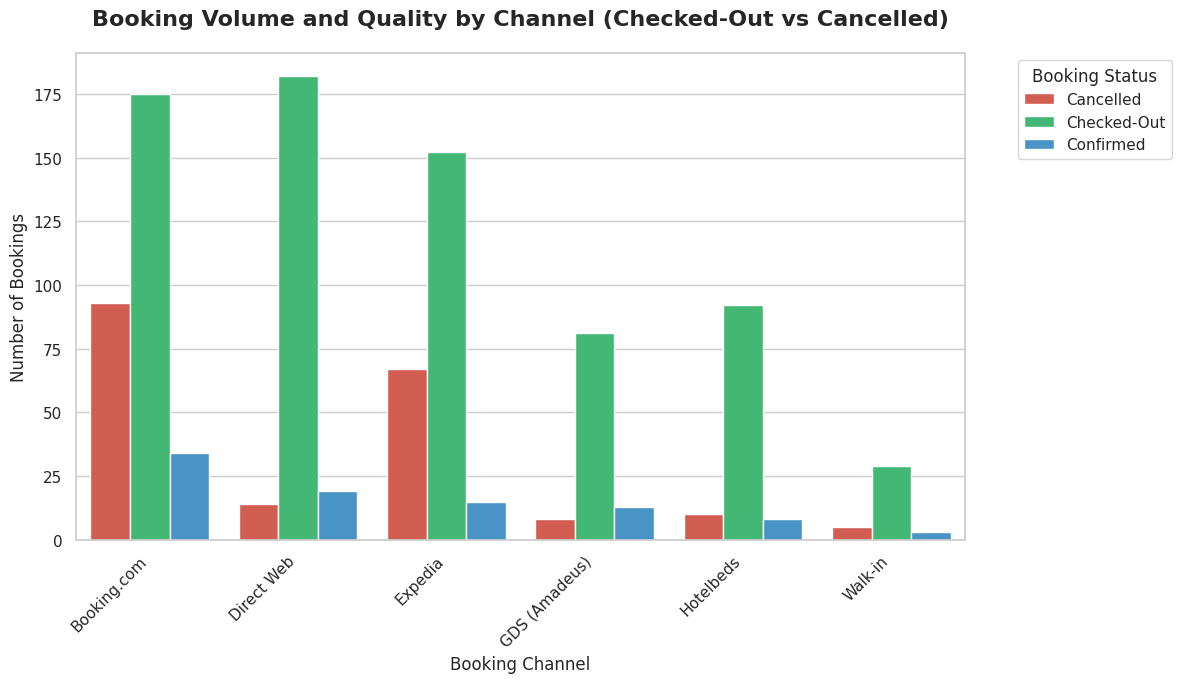


- What to explore: ต้องการดู "คุณภาพของการจอง (Booking Quality)" โดยเปรียบเทียบปริมาณการจองที่เข้าพักสำเร็จ (Checked-Out) เทียบกับปริมาณที่ถูกยกเลิก (Cancelled) ในแต่ละช่องทาง
- Insight: กราฟนี้ช่วยเผยให้เห็นว่าช่องทางที่สร้างยอดจอง (Volume) ได้สูงที่สุด อาจเป็นช่องทางที่มีการยกเลิกสูงที่สุดตามไปด้วย (สังเกตจากแท่งสีแดง) ซึ่งช่วยเน้นย้ำถึงปัญหาการจองแบบเผื่อเลือกของฝั่ง OTA เมื่อเทียบกับช่องทาง Direct Web ที่ลูกค้ามีความตั้งใจเข้าพักจริงมากกว่า
- Recommentation: Direct Web มีอัตราการยกเลิกต่ำมาก (ลูกค้าตั้งใจมาพักจริง) เราควรทำแคมเปญ 'Book Direct & Get More' เช่น การจองตรงจะได้ Early Check-in หรือคูปองอาหาร เพื่อจูงใจให้ลูกค้ากลุ่มคุณภาพย้ายจาก OTA มาจองกับเราโดยตรงครับ



In [ ]:
# เพิ่ม 'Cancelled' เข้าไปใน Filter
status_filter = ['Confirmed', 'Checked-Out', 'Cancelled']
df_filtered = df[df['status'].isin(status_filter)]

# Group by channel name and status to count bookings
bookings_by_status_channel = df_filtered.groupby(['channel_name', 'status']).size().reset_index(name='booking_count')

plt.figure(figsize=(12, 7))

sns.barplot(
    data=bookings_by_status_channel,
    x='channel_name',
    y='booking_count',
    hue='status',
    # เพิ่มสีแดง (#e74c3c) สำหรับ Cancelled เพื่อให้เห็นความแตกต่างชัดเจนว่าเป็นตัวปัญหา
    palette={'Checked-Out': '#2ecc71', 'Confirmed': '#3498db', 'Cancelled': '#e74c3c'}
)

plt.title('Booking Volume and Quality by Channel (Checked-Out vs Cancelled)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Number of Bookings', fontsize=12)
plt.xlabel('Booking Channel', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Booking Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("""
- What to explore: ต้องการดู "คุณภาพของการจอง (Booking Quality)" โดยเปรียบเทียบปริมาณการจองที่เข้าพักสำเร็จ (Checked-Out) เทียบกับปริมาณที่ถูกยกเลิก (Cancelled) ในแต่ละช่องทาง
- Insight: กราฟนี้ช่วยเผยให้เห็นว่าช่องทางที่สร้างยอดจอง (Volume) ได้สูงที่สุด อาจเป็นช่องทางที่มีการยกเลิกสูงที่สุดตามไปด้วย (สังเกตจากแท่งสีแดง) ซึ่งช่วยเน้นย้ำถึงปัญหาการจองแบบเผื่อเลือกของฝั่ง OTA เมื่อเทียบกับช่องทาง Direct Web ที่ลูกค้ามีความตั้งใจเข้าพักจริงมากกว่า
- Recommentation: Direct Web มีอัตราการยกเลิกต่ำมาก (ลูกค้าตั้งใจมาพักจริง) เราควรทำแคมเปญ 'Book Direct & Get More' เช่น การจองตรงจะได้ Early Check-in หรือคูปองอาหาร เพื่อจูงใจให้ลูกค้ากลุ่มคุณภาพย้ายจาก OTA มาจองกับเราโดยตรงครับ
""")